# Configuración Inicial del Proyecto
Este notebook configura el entorno de trabajo instalando las dependencias necesarias y preparando el sistema de archivos dependiendo de si se ejecuta de forma local o en Google Colab.

In [1]:
# Instalación de dependencias (necesarias para parsear y validar la configuración)
!pip install pyyaml pydantic -q

In [2]:
import sys
import os
from pathlib import Path

# 1. Detección de Google Colab y montaje de Drive
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    print("🚀 Entorno: Google Colab detectado. Montando Google Drive...")
    drive.mount('/content/drive')

    # Ruta base del proyecto en Drive
    PROJECT_ROOT = "/content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia"

    # Cambiamos el directorio de trabajo para facilitar ejecuciones relativas
    os.chdir(PROJECT_ROOT)

    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    print(f"✅ Directorio de trabajo establecido en: {PROJECT_ROOT}")

else:
    print("💻 Entorno: Local detectado.")
    # Asumiendo que el notebook se ejecuta desde la carpeta 'notebooks'
    PROJECT_ROOT = str(Path.cwd().parent)

    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    print(f"✅ Ruta del proyecto añadida al sys.path: {PROJECT_ROOT}")

🚀 Entorno: Google Colab detectado. Montando Google Drive...
Mounted at /content/drive
✅ Directorio de trabajo establecido en: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia


## Carga y Validación de Configuración
A continuación, importamos nuestro gestor de entorno (`EnvironmentManager`). Esta clase cargará automáticamente el archivo `config.yaml` y construirá todas las rutas dinámicas, dejándolas disponibles a través de atributos tipados (Pydantic).

In [3]:
# 2. Importar el script config.py (desde la carpeta src) y cargar configuración
from src.config_colab import EnvironmentManager

try:
    env_manager = EnvironmentManager()
    cfg = env_manager.config
    print(f"🎯 Configuración cargada con éxito para el proyecto: {cfg.project.name}")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")

🎯 Configuración cargada con éxito para el proyecto: optimizacion-ia


## Ejemplo de Uso
Demostración de cómo acceder a los parámetros y cómo generar rutas absolutas que funcionarán perfectamente independientemente de si estás en local o en Colab.

In [4]:
# 3. Acceder a los parámetros y validar rutas
print(f"IDE Configurado: {cfg.environment.ide.upper()}")

# Obtener ruta absoluta dinámicamente usando el método get_path
raw_data_path = env_manager.get_path(cfg.paths.data.raw)
trained_models_path = env_manager.get_path(cfg.paths.models.trained)

print(f"\nRuta completa de datos crudos: {raw_data_path}")
print(f"Ruta completa de modelos entrenados: {trained_models_path}")

# Crear directorios automáticamente si no existen (buena práctica)
raw_data_path.mkdir(parents=True, exist_ok=True)
trained_models_path.mkdir(parents=True, exist_ok=True)

print("\n✔️ Estructura de directorios base verificada/creada.")

IDE Configurado: COLAB

Ruta completa de datos crudos: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/data/raw
Ruta completa de modelos entrenados: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/models/trained

✔️ Estructura de directorios base verificada/creada.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from src.config_colab import EnvironmentManager
from src.config_colab import setup_dynamic_logger

# 1. Cargar configuración del proyecto
env = EnvironmentManager()

# 2. Inicializar el logger dinámico
logger, log_file_path = setup_dynamic_logger(env, "00_Configuracion_inicial")

logger.info(f"✅ Inicializando proceso. Archivo de log creado en: {log_file_path.name}")

2026-09-03 19:05:21 [INFO] ✅ Inicializando proceso. Archivo de log creado en: 20260903190521_00_Configuracion_inicial.log
INFO:OptimizacionIA:✅ Inicializando proceso. Archivo de log creado en: 20260903190521_00_Configuracion_inicial.log


In [7]:
logger.info("Generando archivo dummy en la carpeta raw...")

raw_path = env.get_path(env.config.paths.data.raw)
raw_path.mkdir(parents=True, exist_ok=True)
dummy_csv_path = raw_path / "datos_dummy.csv"

# Crear un DataFrame dummy y guardarlo en RAW
df_dummy = pd.DataFrame({
    'mes': ['Ene', 'Feb', 'Mar', 'Abr', 'May'],
    'ventas': [150, 200, 180, 220, 300]
})
df_dummy.to_csv(dummy_csv_path, index=False)

logger.info(f"Archivo guardado exitosamente en: {dummy_csv_path}")

2026-09-03 19:05:47 [INFO] Generando archivo dummy en la carpeta raw...
INFO:OptimizacionIA:Generando archivo dummy en la carpeta raw...
2026-09-03 19:05:47 [INFO] Archivo guardado exitosamente en: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/data/raw/datos_dummy.csv
INFO:OptimizacionIA:Archivo guardado exitosamente en: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/data/raw/datos_dummy.csv


2026-09-03 19:05:52 [INFO] Iniciando lectura de datos raw...
INFO:OptimizacionIA:Iniciando lectura de datos raw...
2026-09-03 19:05:52 [INFO] Datos leídos correctamente. Filas cargadas: 5
INFO:OptimizacionIA:Datos leídos correctamente. Filas cargadas: 5
2026-09-03 19:05:52 [INFO] Generando gráfico de reporte...
INFO:OptimizacionIA:Generando gráfico de reporte...
2026-09-03 19:05:53 [INFO] Reporte guardado exitosamente en: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/reports/figures/tendencia_ventas.png
INFO:OptimizacionIA:Reporte guardado exitosamente en: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/reports/figures/tendencia_ventas.png


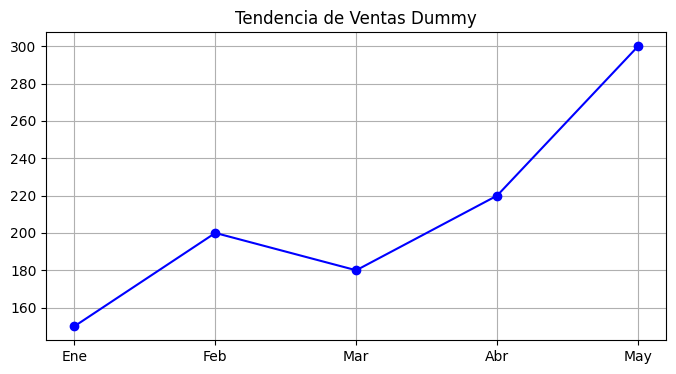

In [8]:
logger.info("Iniciando lectura de datos raw...")

try:
    # 1. Leer el archivo desde RAW
    df_leido = pd.read_csv(dummy_csv_path)
    logger.info(f"Datos leídos correctamente. Filas cargadas: {len(df_leido)}")

    # 2. Procesar y graficar
    logger.info("Generando gráfico de reporte...")
    plt.figure(figsize=(8, 4))
    plt.plot(df_leido['mes'], df_leido['ventas'], marker='o', color='b')
    plt.title('Tendencia de Ventas Dummy')
    plt.grid(True)

    # 3. Guardar en carpeta de reportes/figures
    reports_path = env.get_path(env.config.paths.reports.figures)
    reports_path.mkdir(parents=True, exist_ok=True)
    grafico_path = reports_path / "tendencia_ventas.png"

    plt.savefig(grafico_path)
    logger.info(f"Reporte guardado exitosamente en: {grafico_path}")

    plt.show() # Mostrar en output del notebook

except Exception as e:
    logger.error(f"Error procesando los datos: {e}")

In [9]:
# Leemos las últimas líneas del archivo de log para confirmar que todo se registró
print("\n--- CONTENIDO DEL ARCHIVO DE LOG ---")
with open(log_file_path, 'r', encoding='utf-8') as f:
    print(f.read())


--- CONTENIDO DEL ARCHIVO DE LOG ---
2026-09-03 19:05:21 [INFO] ✅ Inicializando proceso. Archivo de log creado en: 20260903190521_00_Configuracion_inicial.log
2026-09-03 19:05:47 [INFO] Generando archivo dummy en la carpeta raw...
2026-09-03 19:05:47 [INFO] Archivo guardado exitosamente en: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/data/raw/datos_dummy.csv
2026-09-03 19:05:52 [INFO] Iniciando lectura de datos raw...
2026-09-03 19:05:52 [INFO] Datos leídos correctamente. Filas cargadas: 5
2026-09-03 19:05:52 [INFO] Generando gráfico de reporte...
2026-09-03 19:05:53 [INFO] Reporte guardado exitosamente en: /content/drive/MyDrive/MaestriaIngAnalitica/optimizacion-ia/reports/figures/tendencia_ventas.png

